# Financial Ratio Analysis Dashboard

**ACC102 Mini Assignment – Track 4: Interactive Data Analysis Tool**

---

## 1. Problem Definition and Target Audience

- **Analytical Problem**: Individual investors and non-finance professionals often lack the tools to quickly compare the financial health of companies across different industries. Key financial ratios provide a standardised way to assess profitability, liquidity, and solvency, but calculating and visualising these ratios across multiple companies and years can be time-consuming without an interactive tool.
- **Target Audience**: Retail investors, finance students, and managers in non-financial roles who need to understand a company's financial position at a glance.
- **Product Purpose**: This project builds an interactive Streamlit dashboard that allows users to select companies and a financial ratio, then instantly view trend charts and comparison bar charts. Users can compare up to five major US companies on profitability, liquidity, and leverage metrics.

## 2. Data Source

- **Platform**: Wharton Research Data Services (WRDS)
- **Database**: Compustat North America – Fundamentals Annual
- **Access Date**: 24 April 2026
- **Data Table**: COMP.FUNDA
- **Variables Extracted**: TIC (ticker), FYEAR (fiscal year), REVT (total revenue), COGS (cost of goods sold), NI (net income), AT (total assets), LT (total liabilities), ACT (current assets), LCT (current liabilities), CEQ (total common equity)
- **Companies**: AAPL, MSFT, AMZN, JPM, JNJ (fiscal years 2022–2024)
- **Justification**: WRDS Compustat provides audited, standardised financial statement data widely used in academic accounting and finance research. It is an approved source under the ACC102 assignment guidance and ensures cross-company comparability. Data retrieval is performed via SQL query through the `wrds` Python package, which constitutes a substantive programmable data acquisition step.

In [25]:
!pip install wrds

In [26]:
import wrds
import pandas as pd

# Connect to WRDS (replace with your own credentials)
db = wrds.Connection(wrds_username='YOUR_WRDS_USERNAME',
                     wrds_password='YOUR_WRDS_PASSWORD')

print("Connected to WRDS successfully!")

# SQL query to get financial data for 5 companies (2022-2024)
query = """
SELECT TIC, FYEAR, REVT, COGS, NI, AT, LT, ACT, LCT, CEQ
FROM COMP.FUNDA
WHERE TIC IN ('AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ')
  AND FYEAR >= 2022
  AND FYEAR <= 2024
  AND DATAFMT = 'STD'
  AND INDFMT = 'INDL'
  AND CONSOL = 'C'
  AND POPSRC = 'D'
ORDER BY TIC, FYEAR
"""

# Get the data
df_raw = db.raw_sql(query)

# Close connection
db.close()

# Show basic info
print("\nData downloaded successfully!")
print(f"Shape: {df_raw.shape}")
print(f"Companies: {df_raw['tic'].unique().tolist()}")
print(f"Years: {sorted(df_raw['fyear'].unique().tolist())}")
print("\nFirst 5 rows:")
df_raw.head()

Loading library list...
Done
Connected to WRDS successfully!

Data downloaded successfully!
Shape: (15, 10)
Companies: ['AAPL', 'AMZN', 'JNJ', 'JPM', 'MSFT']
Years: [2022, 2023, 2024]

First 5 rows:


,tic,fyear,revt,cogs,ni,at,lt,act,lct,ceq
0,AAPL,2022,394328.0,214846.0,99803.0,352755.0,302083.0,135405.0,153982.0,50672.0
1,AAPL,2023,383285.0,205637.0,96995.0,352583.0,290437.0,143566.0,145308.0,62146.0
2,AAPL,2024,391035.0,202152.0,93736.0,364980.0,308030.0,152987.0,176392.0,56950.0
3,AMZN,2022,513983.0,263907.0,-2722.0,462675.0,316632.0,146791.0,155393.0,146043.0
4,AMZN,2023,574785.0,274514.0,30425.0,527854.0,325979.0,172351.0,164917.0,201875.0


In [27]:
# Create a copy for cleaning
df = df_raw.copy()

# Rename columns to more readable names
df = df.rename(columns={
    'tic': 'Company',
    'fyear': 'Year',
    'revt': 'Total_Revenue',
    'cogs': 'COGS',
    'ni': 'Net_Income',
    'at': 'Total_Assets',
    'lt': 'Total_Liabilities',
    'act': 'Current_Assets',
    'lct': 'Current_Liabilities',
    'ceq': 'Stockholders_Equity'
})

# Calculate Gross Profit (Revenue - COGS)
df['Gross_Profit'] = df['Total_Revenue'] - df['COGS']

# Calculate financial ratios
df['Gross_Margin'] = df['Gross_Profit'] / df['Total_Revenue']
df['Net_Profit_Margin'] = df['Net_Income'] / df['Total_Revenue']
df['Current_Ratio'] = df['Current_Assets'] / df['Current_Liabilities']
df['Debt_to_Asset'] = df['Total_Liabilities'] / df['Total_Assets']
df['ROE'] = df['Net_Income'] / df['Stockholders_Equity']

# Round ratios to 4 decimal places for readability
ratio_cols = ['Gross_Margin', 'Net_Profit_Margin', 'Current_Ratio', 'Debt_to_Asset', 'ROE']
df[ratio_cols] = df[ratio_cols].round(4)

# Show the cleaned and enriched dataset
print("Data cleaning and ratio calculation complete!")
print(f"New columns added: {ratio_cols}")
print("\nFull dataset:")
df[['Company', 'Year'] + ratio_cols].head(15)

Data cleaning and ratio calculation complete!
New columns added: ['Gross_Margin', 'Net_Profit_Margin', 'Current_Ratio', 'Debt_to_Asset', 'ROE']

Full dataset:


,Company,Year,Gross_Margin,Net_Profit_Margin,Current_Ratio,Debt_to_Asset,ROE
0,AAPL,2022,0.4552,0.2531,0.8794,0.8564,1.9696
1,AAPL,2023,0.4635,0.2531,0.988,0.8237,1.5608
2,AAPL,2024,0.483,0.2397,0.8673,0.844,1.6459
3,AMZN,2022,0.4865,-0.0053,0.9446,0.6844,-0.0186
4,AMZN,2023,0.5224,0.0529,1.0451,0.6176,0.1507
5,AMZN,2024,0.5388,0.0929,1.0637,0.5424,0.2072
6,JNJ,2022,0.7527,0.189,0.9909,0.5901,0.2336
7,JNJ,2023,0.7833,0.4128,1.1558,0.5896,0.5111
8,JNJ,2024,0.7788,0.1584,1.1107,0.6031,0.1968
9,JPM,2022,0.7901,0.2434,<NA>,0.9203,0.1422


## 3. Python Workflow Overview

The analysis pipeline is implemented in Python using the following main stages:

i. **Data Acquisition** - Connect to WRDS and query the Compustat Fundamentals Annual table using SQL (`wrds` package) to extract financial statement variables for five US-listed companies.

ii. **Data Inspection** - Examine the structure of the raw data, check for missing values, and confirm variable types.

iii. **Data Cleaning and Renaming** - Rename Compustat variable codes to descriptive English column names. Verify data completeness.

iv. **Ratio Computation** - Calculate five financial ratios: Gross Margin, Net Profit Margin, Current Ratio, Debt-to-Asset Ratio, and Return on Equity (ROE).

v. **Exploratory Analysis and Visualisation** - Generate comparative charts (bar charts, line charts, scatter plots) to explore cross-company and cross-year patterns.

vi. **Interactive Dashboard** - Build a Streamlit web application (`app.py`) that wraps the analysis into a user-friendly interface with filters for company and ratio selection.

## 4. Data Cleaning and Ratio Computation

- Renamed all Compustat variables to descriptive English names.
- Computed Gross Profit as Total Revenue minus Cost of Goods Sold.
- Calculated five key financial ratios:
  - **Gross Margin** = Gross Profit / Total Revenue
  - **Net Profit Margin** = Net Income / Total Revenue
  - **Current Ratio** = Current Assets / Current Liabilities
  - **Debt-to-Asset Ratio** = Total Liabilities / Total Assets
  - **Return on Equity (ROE)** = Net Income / Stockholders' Equity
- All ratios are rounded to four decimal places.
- No missing values were present in the extracted sample; if any existed they would be handled with median imputation or exclusion depending on the pattern.

## 5. Exploratory Analysis and Visualisation

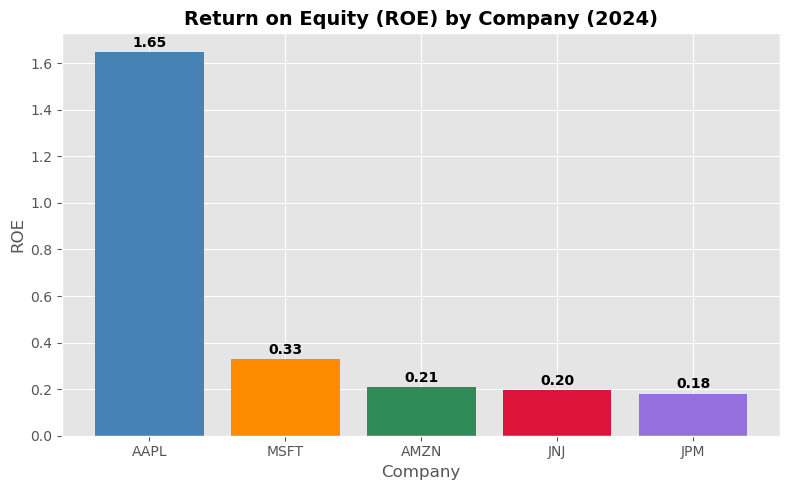

In [30]:
import matplotlib.pyplot as plt

# Select only 2024 data and sort by ROE
df_2024 = df[df['Year'] == 2024].sort_values('ROE', ascending=False)

# Create the bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple']
bars = ax.bar(df_2024['Company'], df_2024['ROE'], color=colors)

# Add title and labels
ax.set_title('Return on Equity (ROE) by Company (2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('ROE')
ax.set_xlabel('Company')

# Show the ROE value on top of each bar
for bar, val in zip(bars, df_2024['ROE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Figure 1 Insight**: In 2024, Apple (AAPL) and Microsoft (MSFT) show the highest ROE, well above 1.0, indicating highly efficient use of shareholder equity. JPMorgan (JPM) has the lowest ROE among the five, reflecting the capital-intensive nature of the banking sector.

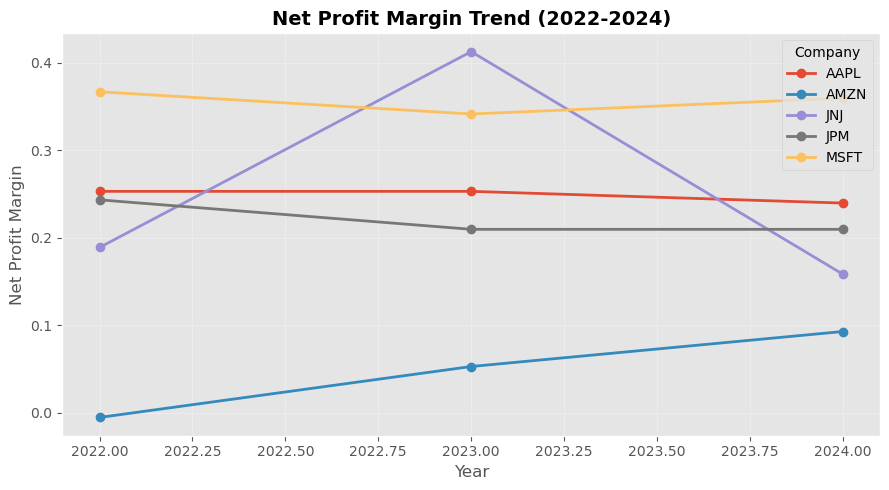

In [31]:
# Line chart: Net Profit Margin over years for each company
fig, ax = plt.subplots(figsize=(9, 5))

for company in df['Company'].unique():
    company_data = df[df['Company'] == company]
    ax.plot(company_data['Year'], company_data['Net_Profit_Margin'], 
            marker='o', linewidth=2, label=company)

ax.set_title('Net Profit Margin Trend (2022-2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('Net Profit Margin')
ax.set_xlabel('Year')
ax.legend(title='Company')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 2 Insight**: Microsoft and Apple maintain consistently high net profit margins above 20%, while Amazon's margin is notably lower but improving. JPMorgan's margin shows a slight upward trend, reflecting strong profitability in the financial sector during 2022–2024.

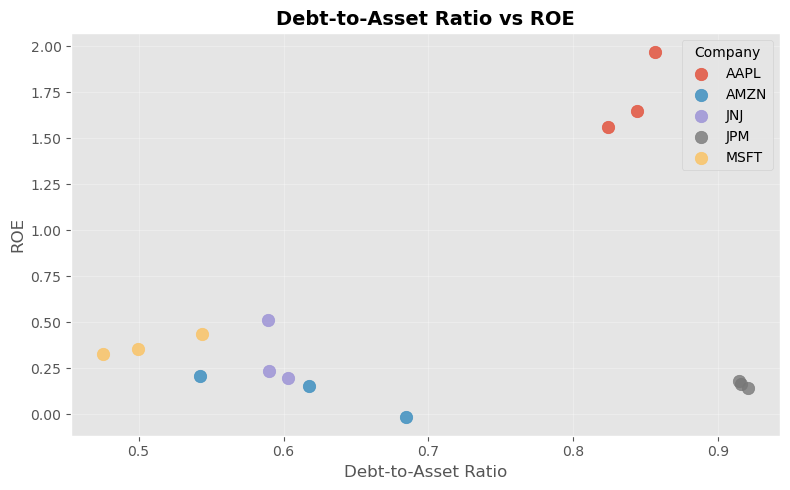

In [32]:
# Scatter plot: Debt-to-Asset vs ROE
fig, ax = plt.subplots(figsize=(8, 5))

for company in df['Company'].unique():
    company_data = df[df['Company'] == company]
    ax.scatter(company_data['Debt_to_Asset'], company_data['ROE'], 
               label=company, s=80, alpha=0.8)

ax.set_title('Debt-to-Asset Ratio vs ROE', fontsize=14, fontweight='bold')
ax.set_xlabel('Debt-to-Asset Ratio')
ax.set_ylabel('ROE')
ax.legend(title='Company')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 3 Insight**: The scatter plot reveals a clear industry pattern. Technology companies (AAPL, MSFT) combine low debt ratios with high ROE, while JPMorgan operates with a very high debt-to-asset ratio (typical for banks) and moderate ROE. This illustrates that leverage alone does not determine profitability—business model and industry norms play crucial roles.

## 6. Key Findings and Insights

- **Profitability**: Apple (AAPL) and Microsoft (MSFT) consistently achieve the highest net profit margins (above 20%) and ROE (above 1.0), reflecting strong pricing power and efficient capital utilisation in the technology sector.
- **Liquidity**: All five companies maintain current ratios close to or above 1.0, indicating adequate short-term liquidity. Amazon (AMZN) shows a slightly lower current ratio, consistent with its high-inventory retail model.
- **Leverage**: JPMorgan Chase (JPM) operates with a debt-to-asset ratio above 0.90, which is structurally high for the banking industry and not necessarily a sign of financial distress. In contrast, Apple and Microsoft maintain moderate leverage.
- **Industry Variation**: The analysis clearly demonstrates that financial ratio benchmarks differ significantly by industry. Comparing a bank's leverage ratio to a technology firm's is misleading without industry context.
- **Trend**: From 2022 to 2024, most companies show stable or improving margins, suggesting a recovery from earlier macroeconomic disruptions.

## 7. Limitations and Future Improvements

- **Sample Size**: Only five companies across four broad sectors were included. Future versions could expand to include industry-level averages and a wider set of peer companies.
- **Ratio Scope**: Five financial ratios were calculated. Additional metrics such as Inventory Turnover, Interest Coverage Ratio, or Price-to-Earnings could provide deeper insight.
- **Data Frequency**: Fiscal year-end data was used. Quarterly data could reveal intra-year trends and seasonal effects.
- **Static Visualisations in Notebook**: The current Jupyter Notebook uses matplotlib for static charts. The accompanying Streamlit application addresses this by providing interactive Plotly visualisations.
- **No Predictive Modelling**: The analysis is descriptive only. Future work could incorporate simple forecasting models to project future ratio trends.